# 05. 손실함수

손실함수는 모델의 예측이 정답과 얼마나 다른지를 하나의 숫자로 표현하는 기준이다.
딥러닝 모델은 손실값을 줄이는 방향으로 가중치를 업데이트한다.
따라서 손실함수는 단순한 평가 도구가 아니라 학습 방향을 정하는 신호이다.

문제 유형에 따라 손실함수는 달라진다. 회귀는 예측값과 실제값의 거리 자체가 중요하므로 MSE나 MAE를 사용한다.
이진 분류는 정답 클래스의 확률을 높이는 방향으로 BCE 계열을 사용한다.
다중 분류는 정답 클래스의 logit이 다른 클래스보다 커지도록 Cross Entropy를 사용한다.

PyTorch에서는 `nn.MSELoss`, `nn.BCELoss`, `nn.BCEWithLogitsLoss`, `nn.CrossEntropyLoss`를 자주 사용한다.
이때 입력으로 확률을 넣는지 logits를 넣는지에 따라 코드가 달라진다. 이 차이를 이해해야 출력층 설계를 안전하게 할 수 있다.

이 노트북에서는 손실값의 크기만 보는 것이 아니라, 손실함수가 모델에게 어떤 방향의 학습 신호를 주는지 확인한다.

# 손실함수 Loss Function

## 이진분류 손실함수 Binary Cross Entropy

$$
\text{Loss} = -\left[y \cdot \log(p) + (1 - y) \cdot \log(1 - p)\right]
$$
- $y$: 실제 값 (0 또는 1)
- $p$: 예측 확률 (0과 1 사이)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


In [3]:
# 자연상수 e = 2.717...

# log
# - 어떤 수를 몇 번 제곱해야 원하는 값이 되는지를 나타내는 함수
# - 딥러닝에서는 보통 및이 자연상수 e인 자연로그 이용
# - log(2.718) == log(e) == 1
# - log(1) == 0
# - log(0.5) ≈ -0.639
# - log(0.1) ≈ -2.303
# - log(0.01) ≈ -4.605

# 확률은 0 ~ 1 사이의 숫자로
# 여기에 log를 적용하면 0 또는 음수가 반환됨
# -> 예측 정확도가 100% == 1 -> log(1) == 0 == 오차가 0
# -> 예측 정확도가 50% == 0.5 -> log(0.5) == 오차가 -0.693
# -> 예측 정확도가 10% == 0.1 -> log(0.1) == 오차가 -2.303
# 오차를 양수로 표시할 수 있도록 -(음수)를 곱해줄 예정

print('정답이 1, 손실이 큰 경우:', -np.log(0.2))
print('정답이 1, 손실이 작은 경우:', -np.log(0.7))

print('정답이 0, 손실이 작은 경우:', -np.log(1 - 0.2))
print('정답이 0, 손실이 큰 경우:', -np.log(1 - 0.7))


정답이 1, 손실이 큰 경우: 1.6094379124341003
정답이 1, 손실이 작은 경우: 0.35667494393873245
정답이 0, 손실이 작은 경우: 0.2231435513142097
정답이 0, 손실이 큰 경우: 1.203972804325936


### NumPy로 이진 교차 엔트로피 손실함수를 직접 구현

In [4]:
def binary_cross_entropy(y_true, y_pred):

    epsilon = 1e-8
    return -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))

y_true = np.array([1, 0, 1, 1])
y_pred = np.array([0.9, 0.1, 0.8, 0.7])

loss = binary_cross_entropy(y_true, y_pred)
loss


np.float64(0.19763486939016456)

###  PyTorch의 BCELoss로 확률과 이진 정답 사이의 손실을 계산
- BCELoss: Sigmoid를 통과한 0~1 사이의 확률과 정답을 비교하는 이진 분류 손실함수

In [7]:
y_true = torch.tensor([1, 0, 1, 1], dtype=torch.float32)
y_pred = torch.tensor([0.9, 0.1, 0.8, 0.7], dtype=torch.float32) # sigmoid(logit)한 결과값

# BCELoss의 첫 번째 인수에는 sigmoid를 통과한 0~1 확률을 전달한다.
criterion = nn.BCELoss()
loss = criterion(y_pred, y_true)
loss

tensor(0.1976)

### BCEWithLogitsLoss
- BCEWithLogitsLoss: Sigmoid 적용 전 logits를 받아 내부에서 Sigmoid와 BCE를 함께 계산하는 손실함수
- sigmoid와 BCE를 한 번에 계산해 극단적인 logits에서도 수치적으로 더 안정적임

In [6]:
logits = torch.tensor([2.173, -2.345, 1.386, -0.405]) # 출력층 선형방정식 결과값
y_true = torch.tensor([1, 0, 1, 1], dtype=torch.float32)

# sigmoid + BCELoss
# 첫 방법은 logits를 sigmoid로 확률로 바꾼 뒤 BCELoss에 전달한다.
p = torch.sigmoid(logits)
criterion = nn.BCELoss()
loss = criterion(p, y_true)
print(loss)

# BCEWithLogitsLoss
# BCEWithLogitsLoss는 sigmoid와 BCE를 한 번에 계산해 극단적인 logits에서도 수치적으로 더 안정적이다.
criterion2 = nn.BCEWithLogitsLoss()
loss = criterion2(logits, y_true)
print(loss)

tensor(0.3346)
tensor(0.3346)


### 예측 정답 확률이 0~1때 BCE(이진 분류 손실 함수) loss가 어떻게 변하는지

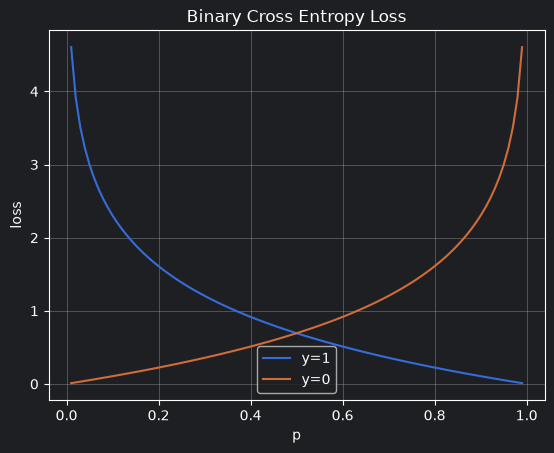

In [8]:
p = np.linspace(0.01, 0.99, 100)

loss_1 = -np.log(p)
loss_0 = -np.log(1 - p)

plt.plot(p, loss_1, label='y=1')
plt.plot(p, loss_0, label='y=0')

plt.title('Binary Cross Entropy Loss')
plt.xlabel('p')
plt.ylabel('loss')
plt.legend()
plt.grid()
plt.show()


## 다중분류 손실함수 Cross Entropy
모델이 출력한 점수(logits)를 softmax 함수로 확률로 바꾼 뒤, 정답 클래스의 log 확률을 취한 값을 손실로 계산한다.

$$
\text{Loss} = -\log(\text{softmax}(\text{logits})[y])
$$

**수식 전체**

$$
\text{Loss} = -\log\left( \frac{e^{z_y}}{\sum_{j} e^{z_j}} \right)
$$

* $z = [z_0, z_1, ..., z_k]$: 각 클래스에 대한 모델의 출력값 (logits)
* $z_y$: 정답 클래스 $y$에 해당하는 로짓 값
* $\sum_j e^{z_j}$: 모든 클래스에 대한 softmax 분모

### softmax 확률에서 정답 클래스의 교차 엔트로피 손실을 직접 계

In [9]:
y_true = 0

z = torch.tensor([2.0, 1.0, 0.1])

p = F.softmax(z, dim=0)
print(p)

pred = p.argmax(dim=0)

loss = -np.log(p.numpy()[y_true])
print(loss)


tensor([0.6590, 0.2424, 0.0986])
0.41702995


### CrossEntropyLoss에 logits와 정수 클래스 정답을 전달해 다중 분류 손실을 계산

In [10]:
y_true = torch.tensor([0], dtype=torch.long) # long만 허용!
z = torch.tensor([[2.0, 1.0, 0.1]])

# 손실함수 CrossEntropyLoss에서 사용할 y 값은 long == int64만 가능


### 정답 클래스 확률에 따른 다중 분류 교차 엔트로피 손실을 시각화

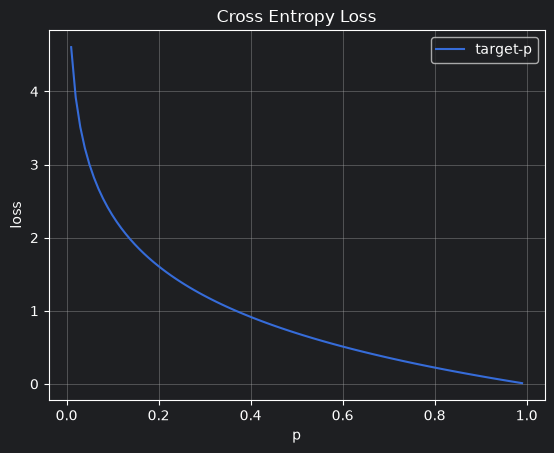

In [11]:
p = np.linspace(0.01, 0.99, 100)

loss = -np.log(p)

plt.plot(p, loss, label='target-p')
plt.title('Cross Entropy Loss')
plt.xlabel('p')
plt.ylabel('loss')
plt.legend()
plt.grid()
plt.show()


## 회귀 손실함수

**1. MSELoss (Mean Squared Error Loss)**

**정의**: 오차(예측 - 실제)의 **제곱** 평균값을 계산

**특징**: 큰 오차에 더 큰 패널티 → 이상치에 민감

**수식**

$$
\text{MSELoss} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

**2. L1Loss 또는 MAELoss (Mean Absolute Error Loss)**

**정의**: 오차(예측 - 실제)의 **절댓값** 평균

**특징**: 이상치에 덜 민감하지만, 미분 불연속점 존재

**수식**

$$
\text{MAELoss} = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$

**3. HuberLoss (Smooth L1 Loss)**

**정의**: 작은 오차에는 MSE처럼, 큰 오차에는 MAE처럼 동작

**특징**: 이상치에 덜 민감하면서도 미분 가능 → **타협형 손실함수**

**수식** (임계값 $\delta$를 기준으로 나뉨)

$$
\text{HuberLoss}(y_i, \hat{y}_i) =
\begin{cases}
\frac{1}{2}(y_i - \hat{y}_i)^2 & \text{if } |y_i - \hat{y}_i| \leq \delta \\
\delta \cdot \left( |y_i - \hat{y}_i| - \frac{1}{2}\delta \right) & \text{otherwise}
\end{cases}
$$

### 이상치 유무에 따른 MSE 문제점

[ 0.5 -0.5 -0.1 -0.8]


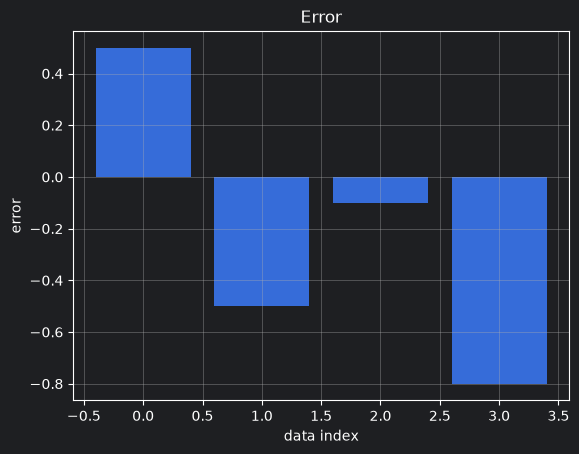

In [12]:
y_true = np.array([3.0, -0.5, 2.0, 7.0])
y_pred = np.array([2.5, 0.0, 2.1, 7.8])

error = y_true - y_pred
print(error)

plt.bar(range(4), error)
plt.title('Error')
plt.xlabel('data index')
plt.ylabel('error')
plt.grid()
plt.show()


[ 0.5 -0.5 -0.1 -0.8 35.5 52.3]


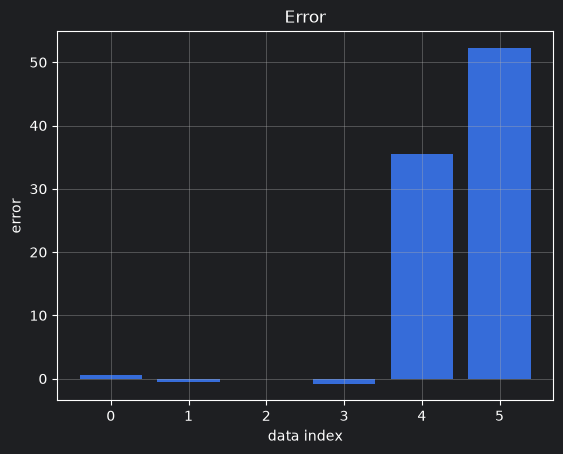

In [13]:
y_true = np.array([3.0, -0.5, 2.0, 7.0, 50.5, 60.0])
y_pred = np.array([2.5, 0.0, 2.1, 7.8, 15.0, 7.7])

error = y_true - y_pred
print(error)

plt.bar(range(6), error)
plt.title('Error')
plt.xlabel('data index')
plt.ylabel('error')
plt.grid()
plt.show()


### NumPy를 이용한 손실함수별 이상치에 대한 민감도 비교

In [14]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def huber_loss(y_true, y_pred, delta=1.0):
    """
    delta보다 작은 오차에는 MSE처럼,
    delta보다 큰 오차에는 MAE처럼 작동한다.
    """
    error = y_true - y_pred
    is_small_error = error <= delta
    return np.mean(
        np.where(is_small_error,
            0.5 * (error ** 2),
            delta * (np.abs(error) - 0.5 * delta)
        ))

y_true = np.array([3.0, -0.5, 2.0, 7.0, 50.5, 60.0])
y_pred = np.array([2.5, 0.0, 2.1, 7.8, 15.0, 7.7])

print('mse: ', mse(y_true, y_pred))
print('mae: ', mae(y_true, y_pred))
print('huber_loss: ', huber_loss(y_true, y_pred))


mse:  666.1149999999999
mae:  14.949999999999998
huber_loss:  14.5625


### PyTorch를 이용한 손실함수별 이상치에 대한 민감도 비교

In [15]:
y_true = torch.tensor([3.0, -0.5, 2.0, 7.0, 50.5, 60.0])
y_pred = torch.tensor([2.5, 0.0, 2.1, 7.8, 15.0, 7.7])

# F.mse_loss 같은 함수형 API와 nn.MSELoss() 같은 모듈 API는 같은 기본 설정에서 같은 값을 반환한다.
print('mse: ', F.mse_loss(y_true, y_pred), nn.MSELoss()(y_true, y_pred))
print('mae: ', F.l1_loss(y_true, y_pred), nn.L1Loss()(y_true, y_pred))
print('huber_loss: ', F.huber_loss(y_true, y_pred), nn.HuberLoss()(y_true, y_pred))
print('smooth_l1_loss: ', F.smooth_l1_loss(y_true, y_pred), nn.SmoothL1Loss()(y_true, y_pred))

mse:  tensor(666.1150) tensor(666.1150)
mae:  tensor(14.9500) tensor(14.9500)
huber_loss:  tensor(14.5625) tensor(14.5625)
smooth_l1_loss:  tensor(14.5625) tensor(14.5625)


### 오차 크기에 따른 MSE, MAE, Huber 손실 곡선을 비교

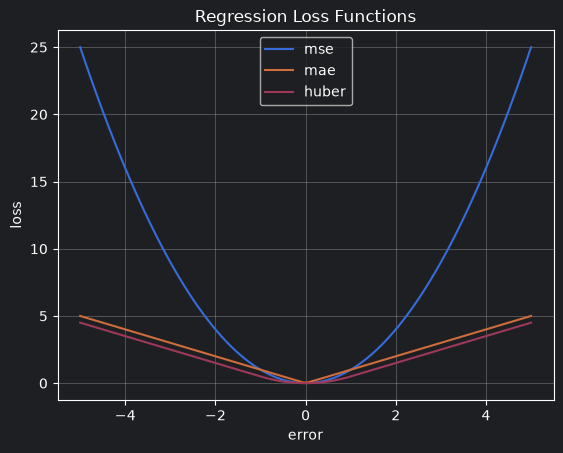

In [16]:
errors = torch.linspace(-5, 5, 100)

mse_fn = nn.MSELoss(reduction='none')
mae_fn = nn.L1Loss(reduction='none')
huber_fn = nn.HuberLoss(reduction='none')

y_true = torch.zeros_like(errors)
y_pred = errors

mse_loss = mse_fn(y_pred, y_true).numpy()
mae_loss = mae_fn(y_pred, y_true).numpy()
huber_loss = huber_fn(y_pred, y_true).numpy()
errors = errors.numpy()

plt.plot(errors, mse_loss, label='mse')
plt.plot(errors, mae_loss, label='mae')
plt.plot(errors, huber_loss, label='huber')

plt.title('Regression Loss Functions')
plt.legend()
plt.xlabel('error')
plt.ylabel('loss')
plt.legend()
plt.grid()
plt.show()


## 손실함수에 따른 모델학습 비교

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=1000,
    n_features=5,
    noise=30,
    random_state=42
)
print(X.shape, y.shape)

np.random.seed(42)
n_outliers = 10
indices = np.random.choice(len(y), size=n_outliers, replace=False)
X[indices] += np.random.normal(500, 100, size=X[indices].shape)
y[indices] += np.random.normal(500, 100, size=n_outliers)

X_scaler = StandardScaler()
y_scaler = StandardScaler()
X = X_scaler.fit_transform(X)
y = y_scaler.fit_transform(y.reshape(-1, 1)).flatten()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

loss_fns = {
    'mse': nn.MSELoss(),
    'mae': nn.L1Loss(),
    'huber': nn.HuberLoss(),
}
loss_results = {}

torch.manual_seed(42)

for name, loss_fn in loss_fns.items():
    model = nn.Linear(5, 1)
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    losses = []

    model.train()
    for epoch in range(500):
        optimizer.zero_grad()
        pred = model(X_train)
        loss = loss_fn(pred, y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        eval_loss_fn = nn.MSELoss()
        pred = model(X_test)
        eval_loss = eval_loss_fn(pred, y_test)
        print(f'{name} 손실함수 학습 결과: MSE {eval_loss.item()}')
        loss_results[name] = losses


(1000, 5) (1000,)
mse 손실함수 학습 결과: MSE 1.9068163633346558
mae 손실함수 학습 결과: MSE 0.7457681894302368
huber 손실함수 학습 결과: MSE 1.218753695487976


### MSE, MAE, Huber로 학습한 모델의 epoch별 학습 손실 시각화

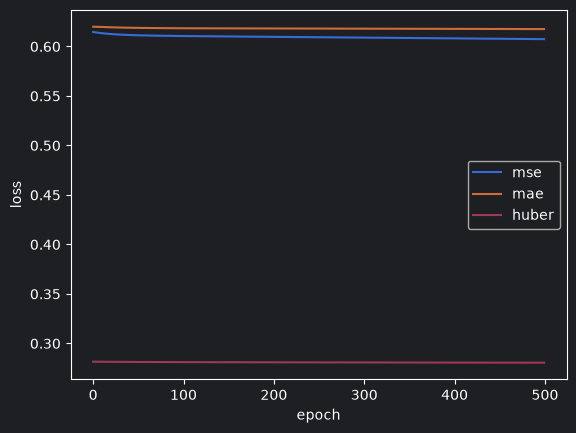

In [18]:
for name, losses in loss_results.items():
    plt.plot(losses, label=name)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()


## 이상치 탐지

이상치가 존재하면 MAE, Huber 손실 함수를 선택하는 방법으로 영향을 줄일 수 있지만,
이상치 자체를 미리 탐지하여 처리하는 방법으로도 영향을 줄일 수 있다.

### 이상치 탐지 방법
- IQR : IQR 1.5배수 범위 밖을 이상치로 간주
- 표준점수 (Z-Score) : 3표준편차 밖의 데이터를 이상치로 간주
- IsolationForest : 트리분할에 근거해서 쉽게 분리되는 데이터를 이상치로 간주
- BoxPlot/ScatterPlot : 시각적으로 이상치를 구분

### IQR 규칙으로 정답 데이터의 이상치 후보 인덱스 찾기

In [19]:
Q1 = np.percentile(y, 25)
Q3 = np.percentile(y, 75)
IQR = Q3 - Q1

lower_bound = Q1 - IQR * 1.5
upper_bound = Q3 + IQR * 1.5

outliers = np.where((y < lower_bound) | (y > upper_bound))[0]
print('outlier개수: ', len(outliers))
print(outliers)


outlier개수:  21
[ 76  94 130 136 138 230 352 411 428 513 521 626 660 678 737 740 744 789
 839 854 859]


### z-score로 평균에서 3표준편차 이상 떨어진 이상치 후보

In [20]:
from scipy.stats import zscore

zscores = zscore(y)
threshold = 3

outliers = np.where(np.abs(zscores) > threshold)[0]
print('이상치개수: ', len(outliers))
print(outliers)


이상치개수:  10
[136 411 513 521 626 660 678 737 740 859]


### Sciket-learn의 IsolationForest로 정답 데이터 이상치 후보 탐지

In [21]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(random_state=42, contamination=0.01)

pred = isolation_forest.fit_predict(y.reshape(-1, 1))
outliers = np.where(pred == -1)[0]
print('이상치개수: ', len(outliers))
print(outliers)


이상치개수:  10
[136 411 521 626 660 678 737 740 789 859]


### boxplot으로 정답 데이터의 중앙값, IQR과 이상치 후보 시각화

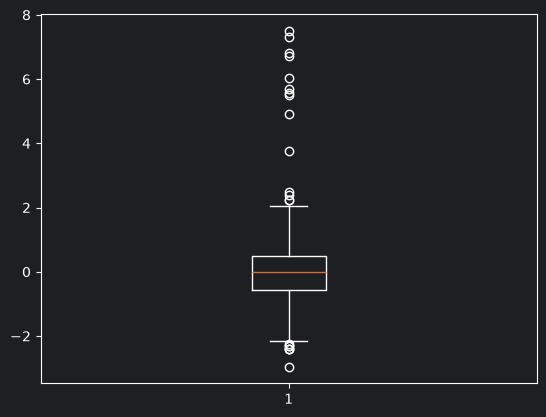

In [22]:
plt.boxplot(y)
plt.show()
